In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou

,preco,hospedes,quartos,camas,tipo_de_quarto,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,...,banheiros,tipo_quarto_casa_apto_inteiro,tipo_quarto_quarto_compartilhado,tipo_quarto_quarto_hotel,tipo_quarto_quarto_privativo,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,casa_apto_inteiro,4.93,2,86,entire condo,-22.982818,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,casa_apto_inteiro,NaN,5,0,entire rental unit,-22.984090,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,casa_apto_inteiro,NaN,1,0,entire rental unit,-22.814911,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,quarto_privativo,5.00,2,3,private room in rental unit,-22.981910,...,1.0,0,0,0,1,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,casa_apto_inteiro,4.91,2,11,entire rental unit,-23.010000,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             38670 non-null  float64
 1   hospedes                          43068 non-null  int64  
 2   quartos                           42096 non-null  float64
 3   camas                             38660 non-null  float64
 4   tipo_de_quarto                    43068 non-null  str    
 5   nota_avaliacao                    33882 non-null  float64
 6   noites_minimas                    43068 non-null  int64  
 7   quantidade_avaliacoes             43068 non-null  int64  
 8   tipo_de_propriedade               43068 non-null  str    
 9   latitude                          43068 non-null  float64
 10  longitude                         43068 non-null  float64
 11  bairro                            43068 non-null  str    
 12  ano            

In [4]:
df["preco"].describe()

#antes do tratamento de outliers

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: preco, dtype: float64

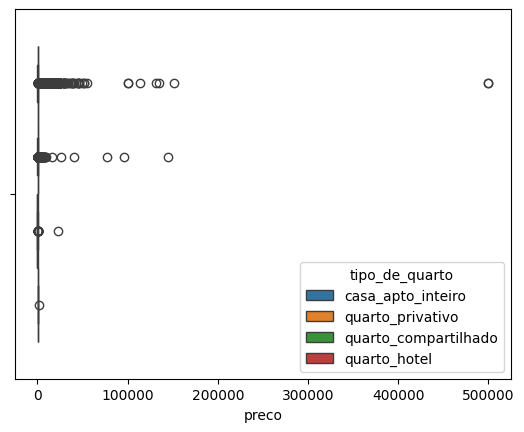

In [5]:
sns.boxplot(x=df["preco"], hue=df["tipo_de_quarto"])
plt.show()

plt.show()

#grafico para avaliar os outliers no dataframe sem tratamento dos outliers

In [6]:
#outliers
df["preco"].sort_values(ascending=False).head(20)
#verificando valores

7624     500000.0
15026    500000.0
16440    151710.0
21203    144800.0
13282    134358.0
42536    131400.0
24598    114118.0
14389    100000.0
13880    100000.0
27939     96547.0
3146      76956.0
1854      55394.0
24256     51545.0
18525     51429.0
24053     50000.0
10694     45900.0
12548     45818.0
34736     45000.0
24697     45000.0
4401      42924.0
Name: preco, dtype: float64

In [7]:
print(df["preco"].quantile([0.90, 0.95, 0.99, 1.0]))
#mostra a distribuição dos preços, e justifica a decisão de cortar os valores acima de 7000

0.90      1097.00
0.95      1880.55
0.99      7125.31
1.00    500000.00
Name: preco, dtype: float64


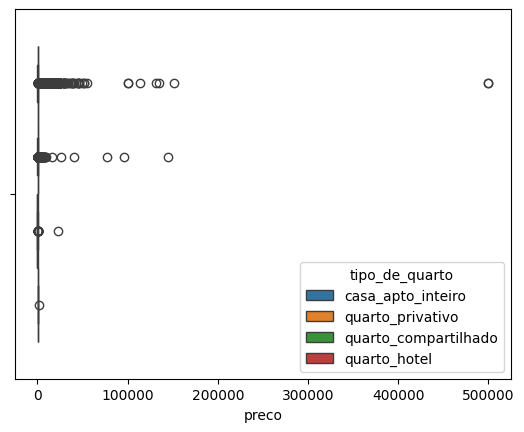

In [8]:
sns.boxplot(x=df["preco"], hue=df["tipo_de_quarto"])
plt.show()

plt.show()

In [9]:
df_tratado = df[df["preco"] <= 7000].copy()

#Limita o preco das diaria ate 13k

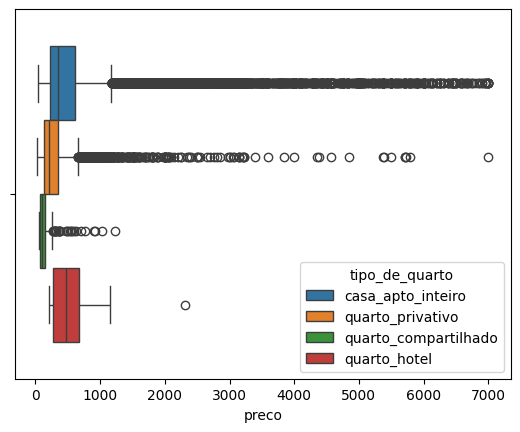

In [10]:
sns.boxplot(x=df_tratado["preco"], hue=df_tratado["tipo_de_quarto"])
plt.show()

plt.show()

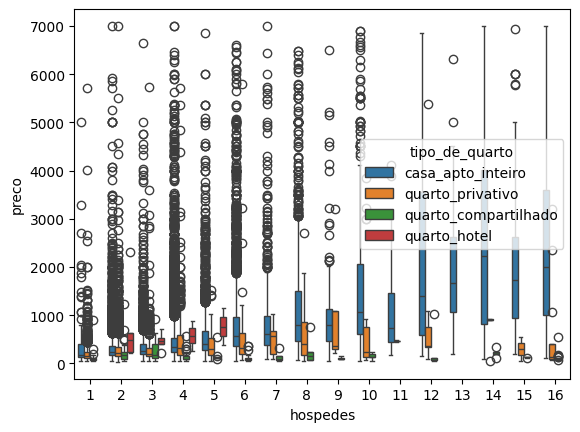

In [11]:
sns.boxplot(x="hospedes", y="preco", hue="tipo_de_quarto", data=df_tratado)
plt.show()

In [12]:
df.shape[0], df_tratado.shape[0]

#mostra os dois dataframes

(43068, 38279)

In [13]:
print(f"Antes: {df.shape[0]} linhas")
print(f"Depois: {df_tratado.shape[0]} linhas")
print(f"Removidos: {df.shape[0] - df_tratado.shape[0]} linhas")

Antes: 43068 linhas
Depois: 38279 linhas
Removidos: 4789 linhas


In [14]:
df_tratado["preco"].describe()

count    38279.000000
mean       527.630189
std        692.222198
min         30.000000
25%        201.000000
50%        315.000000
75%        550.000000
max       7000.000000
Name: preco, dtype: float64

In [15]:
df["preco"].sort_values(ascending=True).head(20)

#mostra valores em forma crescente

5386     30.0
6624     39.0
9388     40.0
42145    41.0
10249    42.0
24389    43.0
11471    43.0
42673    44.0
21734    44.0
14333    46.0
27704    46.0
4048     46.0
8908     46.0
6474     47.0
22890    48.0
9135     48.0
9908     48.0
37698    48.0
7530     48.0
8598     48.0
Name: preco, dtype: float64

In [16]:
contagem = df["banheiros"].value_counts().reset_index()
contagem.columns = ["banheiros", "contagem"]
contagem = contagem.sort_values("banheiros").reset_index(drop=True)

contagem["percentual"] = (contagem["contagem"] / contagem["contagem"].sum() * 100).round(2)
contagem["percentual_acumulado"] = contagem["percentual"].cumsum().round(2)

contagem

,banheiros,contagem,percentual,percentual_acumulado
0,0.0,340,0.80,0.80
1,1.0,27294,63.91,64.71
2,1.5,2158,5.05,69.76
3,2.0,8323,19.49,89.25
4,2.5,1136,2.66,91.91
5,3.0,1734,4.06,95.97
6,3.5,430,1.01,96.98
7,4.0,430,1.01,97.99
8,4.5,171,0.40,98.39
9,5.0,195,0.46,98.85


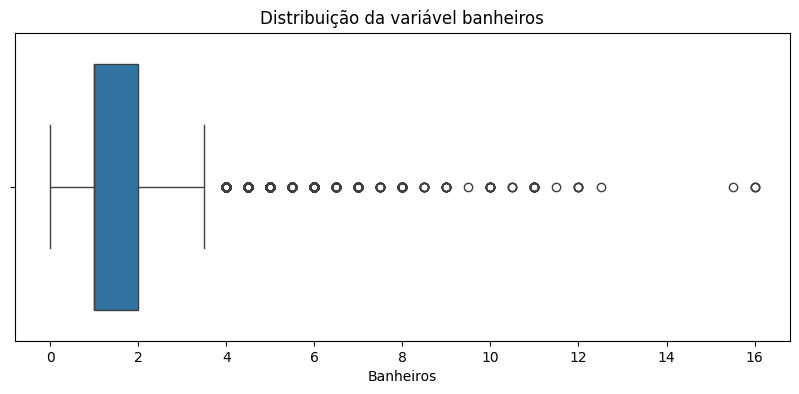

In [17]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["banheiros"])

plt.title("Distribuição da variável banheiros")
plt.xlabel("Banheiros")
plt.show()

In [18]:
contagem = df["quartos"].value_counts().reset_index()
contagem.columns = ["quartos", "contagem"]
contagem = contagem.sort_values("quartos").reset_index(drop=True)

contagem["percentual"] = (contagem["contagem"] / contagem["contagem"].sum() * 100).round(2)
contagem["percentual_acumulado"] = contagem["percentual"].cumsum().round(2)

contagem

,quartos,contagem,percentual,percentual_acumulado
0,0.0,1629,3.87,3.87
1,1.0,25082,59.58,63.45
2,2.0,10046,23.86,87.31
3,3.0,3908,9.28,96.59
4,4.0,836,1.99,98.58
5,5.0,335,0.80,99.38
6,6.0,139,0.33,99.71
7,7.0,62,0.15,99.86
8,8.0,16,0.04,99.90
9,9.0,5,0.01,99.91


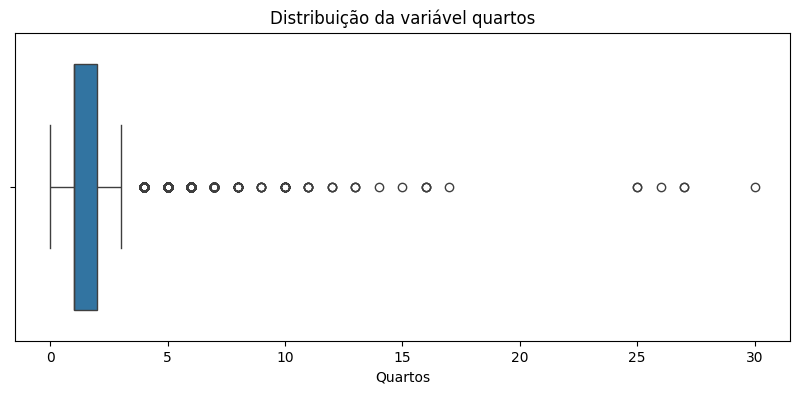

In [19]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["quartos"])

plt.title("Distribuição da variável quartos")
plt.xlabel("Quartos")
plt.show()

In [20]:
df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers

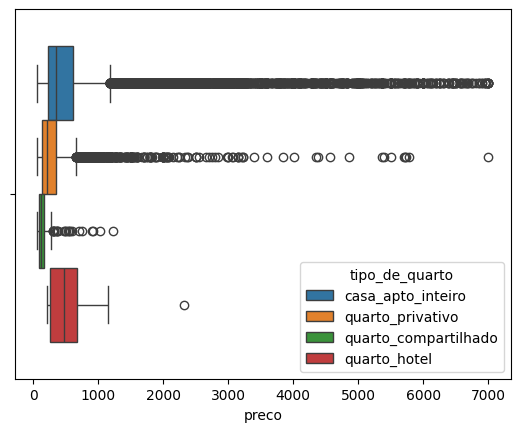

In [21]:
sns.boxplot(x=df_tratado_price_min["preco"], hue=df_tratado_price_min["tipo_de_quarto"])
plt.show()

plt.show()

In [22]:
print(df_tratado_price_min["preco"].quantile([0.90, 0.95, 0.99, 1.0]))

0.90    1028.0
0.95    1632.0
0.99    4000.0
1.00    7000.0
Name: preco, dtype: float64


In [23]:
print(f"Antes: {df_tratado.shape[0]} linhas")
print(f"Depois: {df_tratado_price_min.shape[0]} linhas")
print(f"Removidos: {df_tratado.shape[0] - df_tratado_price_min.shape[0]} linhas")

Antes: 38279 linhas
Depois: 37711 linhas
Removidos: 568 linhas


In [24]:
df_tratado_price_min["preco"].describe()

count    37711.000000
mean       531.505105
std        693.419011
min         65.000000
25%        204.000000
50%        316.000000
75%        553.000000
max       7000.000000
Name: preco, dtype: float64

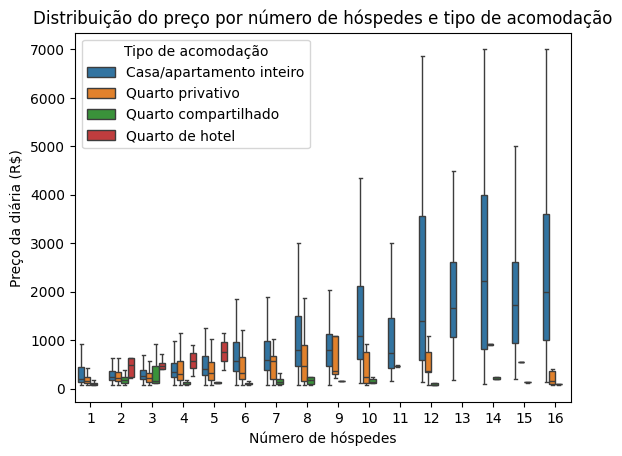

In [25]:
#ESSE VAI SER USADO NA APRESENTAÇÃO
traducao = {
    "casa_apto_inteiro": "Casa/apartamento inteiro",
    "quarto_privativo": "Quarto privativo",
    "quarto_hotel": "Quarto de hotel",
    "quarto_compartilhado": "Quarto compartilhado"
}
 
# Copiando e traduzindo a coluna

df_temp = df_tratado_price_min.copy()
df_temp["tipo_de_quarto"] = df_temp["tipo_de_quarto"].map(traducao)

sns.boxplot(data=df_temp,
            x="hospedes",
            y="preco", 
            hue="tipo_de_quarto",
            showfliers=False)

plt.title("Distribuição do preço por número de hóspedes e tipo de acomodação")
plt.xlabel("Número de hóspedes")
plt.ylabel("Preço da diária (R$)")
 
plt.legend(title="Tipo de acomodação")
plt.show()

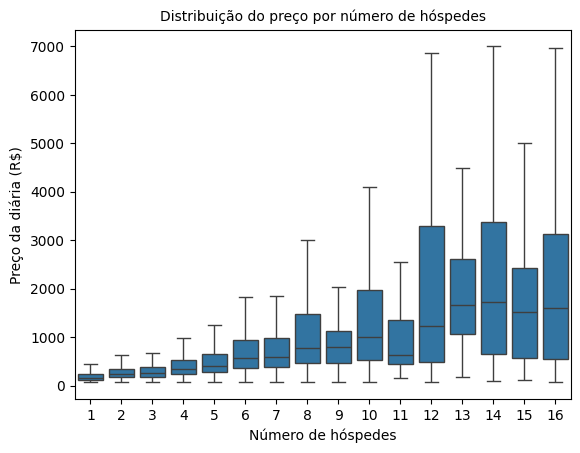

In [27]:
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min, showfliers=False)
plt.title("Distribuição do preço por número de hóspedes", fontsize=10)
plt.xlabel("Número de hóspedes")
plt.ylabel("Preço da diária (R$)")
plt.show()

In [28]:
print("Registros originais:", len(df_tratado))
print("Registros após remoção de outliers:", len(df_tratado_price_min))

Registros originais: 38279
Registros após remoção de outliers: 37711


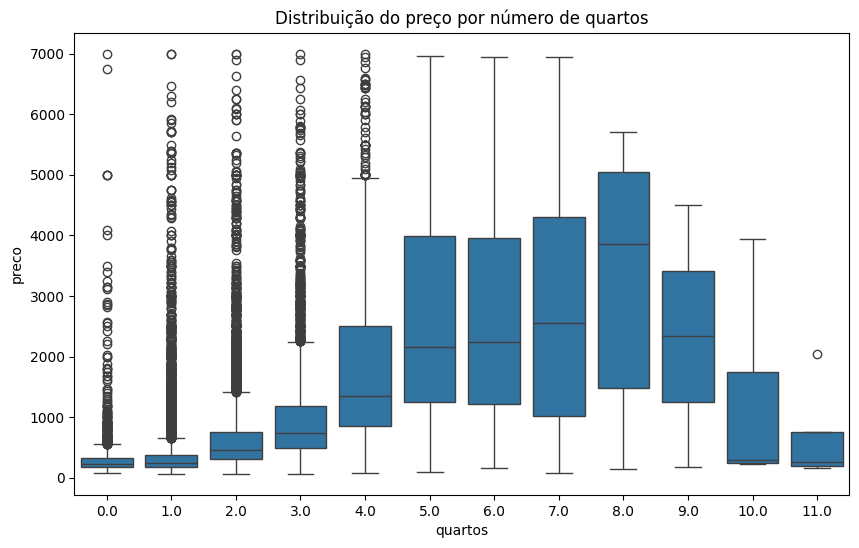

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco"
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.show()

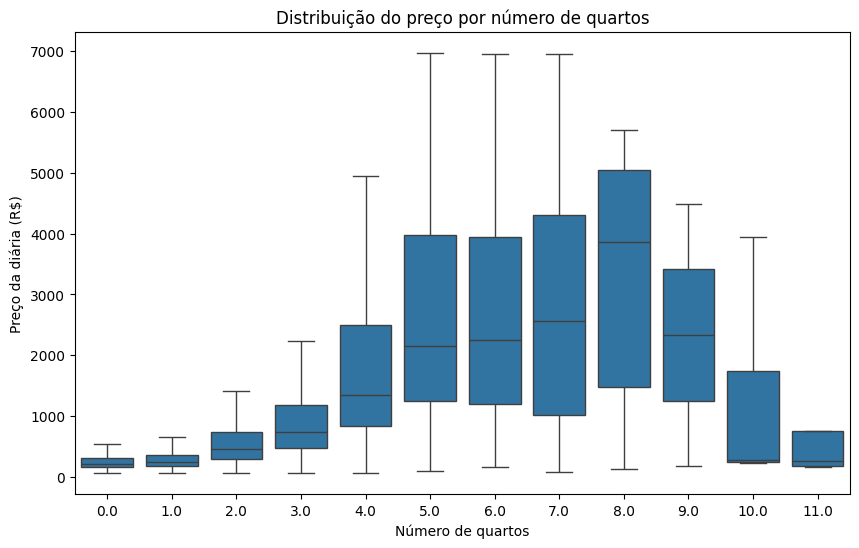

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.xlabel("Número de quartos")
plt.ylabel("Preço da diária (R$)")
plt.show()

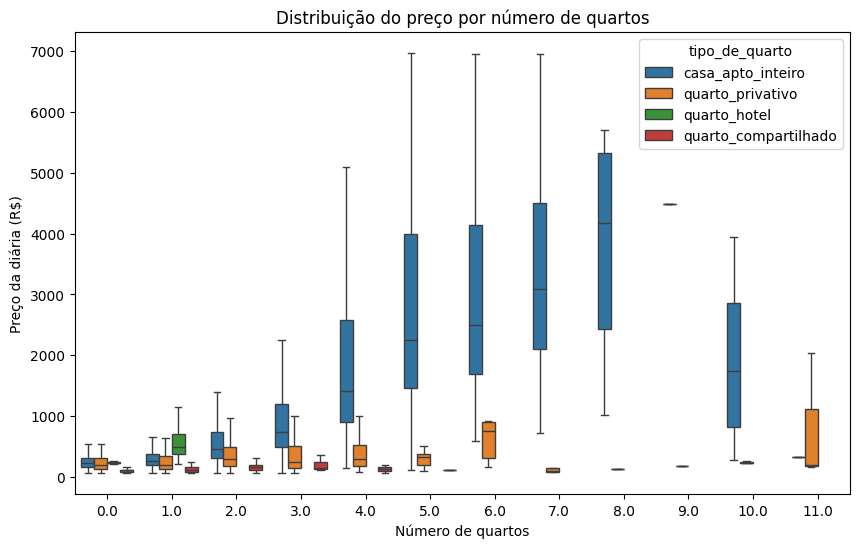

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco",
    hue="tipo_de_quarto",
    showfliers=False
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.xlabel("Número de quartos")
plt.ylabel("Preço da diária (R$)")
plt.show()

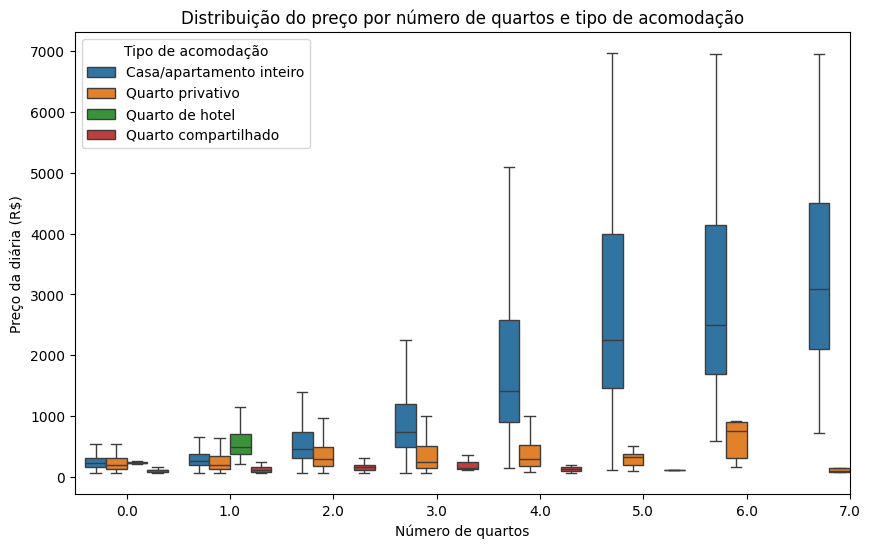

In [32]:
#USAR ESSE NA APRESENTAÇÃO
traducao = {
    "casa_apto_inteiro": "Casa/apartamento inteiro",
    "quarto_privativo": "Quarto privativo",
    "quarto_hotel": "Quarto de hotel",
    "quarto_compartilhado": "Quarto compartilhado"
}
 
# Copiando e traduzindo a coluna

df_temp = df_tratado_price_min.copy()
df_temp["tipo_de_quarto"] = df_temp["tipo_de_quarto"].map(traducao)
 
plt.figure(figsize=(10, 6))
 
sns.boxplot(
    data=df_temp,                  # ✅ usa o dataframe traduzido
    x="quartos",
    y="preco",
    hue="tipo_de_quarto",
    showfliers=False
)
 
plt.title("Distribuição do preço por número de quartos e tipo de acomodação")
plt.xlim(-0.5, 7.0)
plt.xlabel("Número de quartos")
plt.ylabel("Preço da diária (R$)")
 
plt.legend(title="Tipo de acomodação")  # ✅ legenda automática
plt.show()

In [33]:
print(df_tratado_price_min["tipo_de_quarto"].unique())

<ArrowStringArray>
['casa_apto_inteiro', 'quarto_privativo', 'quarto_compartilhado',
 'quarto_hotel']
Length: 4, dtype: str


In [34]:
df_box_banheiros = df_tratado_price_min[df_tratado_price_min["banheiros"] <=6].copy()

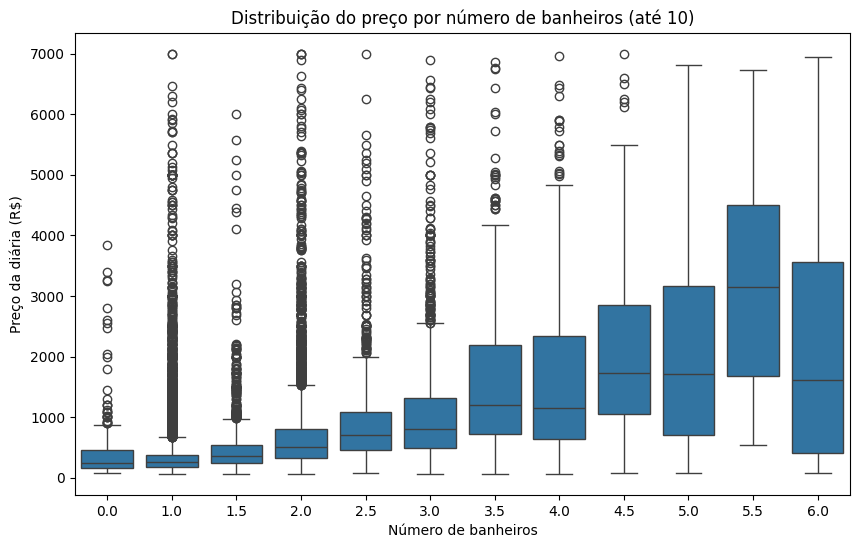

<class 'pandas.DataFrame'>
Index: 37565 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37565 non-null  float64
 1   hospedes                          37565 non-null  int64  
 2   quartos                           37565 non-null  float64
 3   camas                             37554 non-null  float64
 4   tipo_de_quarto                    37565 non-null  str    
 5   nota_avaliacao                    30033 non-null  float64
 6   noites_minimas                    37565 non-null  int64  
 7   quantidade_avaliacoes             37565 non-null  int64  
 8   tipo_de_propriedade               37565 non-null  str    
 9   latitude                          37565 non-null  float64
 10  longitude                         37565 non-null  float64
 11  bairro                            37565 non-null  str    
 12  ano                 

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco"
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária (R$)")

plt.show()
df_box_banheiros.info()

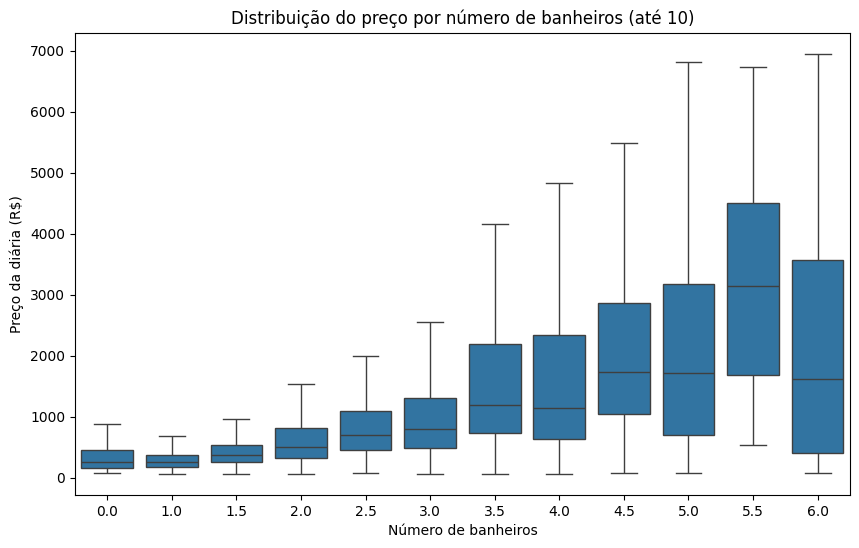

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária (R$)")

plt.show()

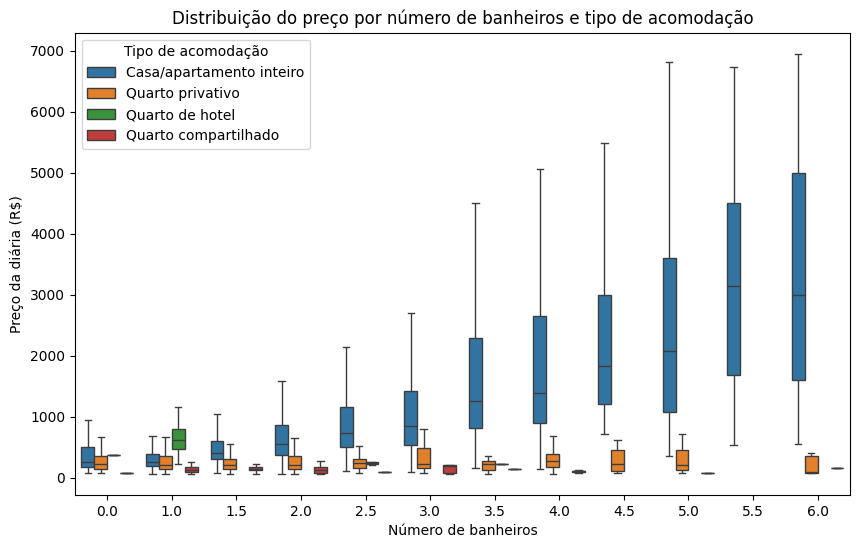

In [37]:
#ESSE VAI SER USADO NA APRESENTAÇÃO
df_temp = df_box_banheiros.copy()
df_temp["tipo_de_quarto"] = df_temp["tipo_de_quarto"].map(traducao)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_temp,
    x="banheiros",
    y="preco",
    hue="tipo_de_quarto",
    showfliers=False
)

plt.title("Distribuição do preço por número de banheiros e tipo de acomodação")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária (R$)")
plt.legend(title="Tipo de acomodação") 

plt.show()

In [38]:
df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_de_quarto"
    ]
].describe()
df_tratado_price_min.info()

<class 'pandas.DataFrame'>
Index: 37711 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37711 non-null  float64
 1   hospedes                          37711 non-null  int64  
 2   quartos                           37711 non-null  float64
 3   camas                             37700 non-null  float64
 4   tipo_de_quarto                    37711 non-null  str    
 5   nota_avaliacao                    30097 non-null  float64
 6   noites_minimas                    37711 non-null  int64  
 7   quantidade_avaliacoes             37711 non-null  int64  
 8   tipo_de_propriedade               37711 non-null  str    
 9   latitude                          37711 non-null  float64
 10  longitude                         37711 non-null  float64
 11  bairro                            37711 non-null  str    
 12  ano                 

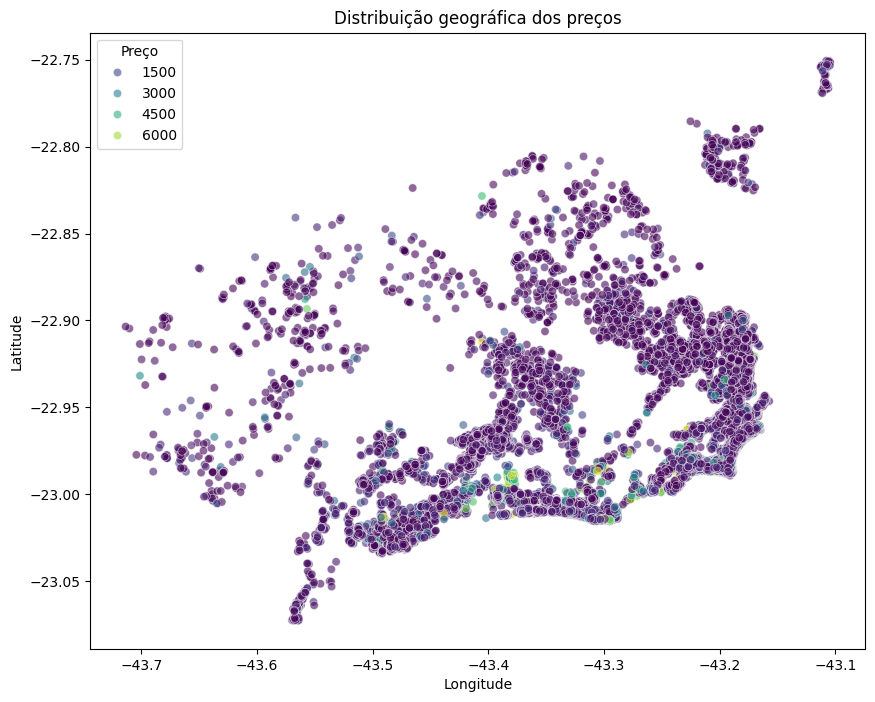

In [39]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tratado_price_min,
    x="longitude",
    y="latitude",
    hue="preco",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço", loc="best")
plt.show()

In [40]:
df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)
df_tratado_price_min.info()

<class 'pandas.DataFrame'>
Index: 37711 entries, 0 to 43067
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37711 non-null  float64
 1   hospedes                          37711 non-null  int64  
 2   quartos                           37711 non-null  float64
 3   camas                             37700 non-null  float64
 4   tipo_de_quarto                    37711 non-null  str    
 5   nota_avaliacao                    30097 non-null  float64
 6   noites_minimas                    37711 non-null  int64  
 7   quantidade_avaliacoes             37711 non-null  int64  
 8   tipo_de_propriedade               37711 non-null  str    
 9   latitude                          37711 non-null  float64
 10  longitude                         37711 non-null  float64
 11  bairro                            37711 non-null  str    
 12  ano                 

In [41]:
media_localizacao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)

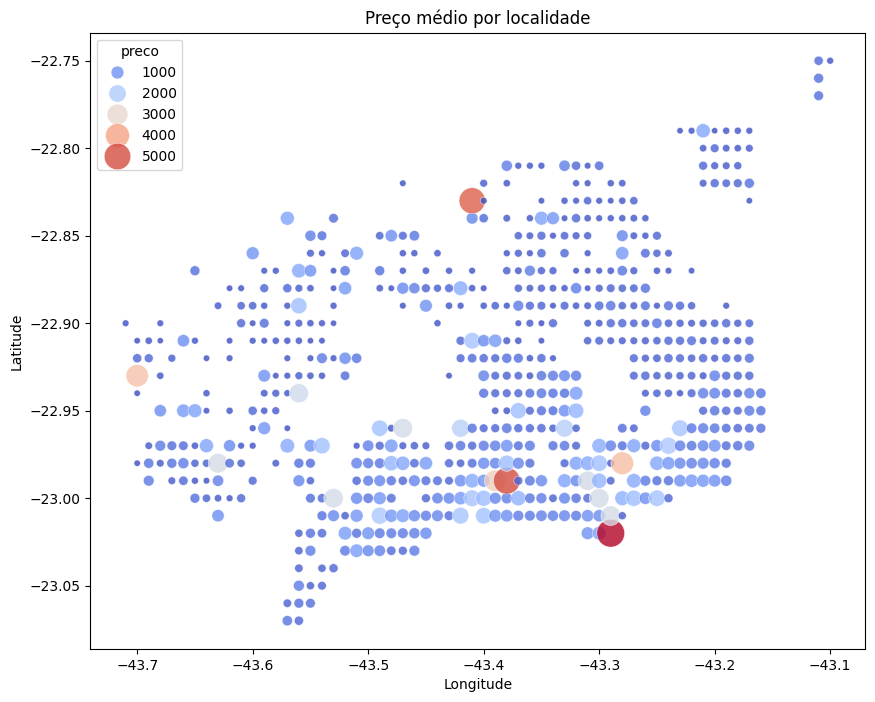

In [42]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=media_localizacao,
    x="lon_bin",
    y="lat_bin",
    size="preco",
    hue="preco",
    palette="coolwarm",
    sizes=(20, 400),
    alpha=0.8
)

plt.title("Preço médio por localidade")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [43]:

total_registros = len(df_tratado_price_min)

freq_absoluta = df_tratado_price_min["tipo_de_quarto"].value_counts()
freq_relativa = freq_absoluta / total_registros

df_frequencia = pd.DataFrame({
    "Tipo de imóvel": freq_absoluta.index,
    "Frequência absoluta": freq_absoluta.values,
    "Frequência relativa": freq_relativa.values,
    "Frequência (%)": (freq_relativa.values * 100).round(2)
})

df_frequencia = df_frequencia.reset_index(drop=True)



df_frequencia


,Tipo de imóvel,Frequência absoluta,Frequência relativa,Frequência (%)
0,casa_apto_inteiro,30841,0.817825,81.78
1,quarto_privativo,6565,0.174087,17.41
2,quarto_compartilhado,290,0.007690,0.77
3,quarto_hotel,15,0.000398,0.04


In [44]:


df_media = df_tratado_price_min.groupby("tipo_de_quarto")["preco"].mean().reset_index()
df_media.columns = ["Tipo de quarto", "Preço médio"]
df_media["Preço médio"] = df_media["Preço médio"].round(2)
df_media

,Tipo de quarto,Preço médio
0,casa_apto_inteiro,580.75
1,quarto_compartilhado,157.29
2,quarto_hotel,619.80
3,quarto_privativo,316.50


C:\Users\XE234PC\AppData\Local\Temp\ipykernel_32980\2974704075.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


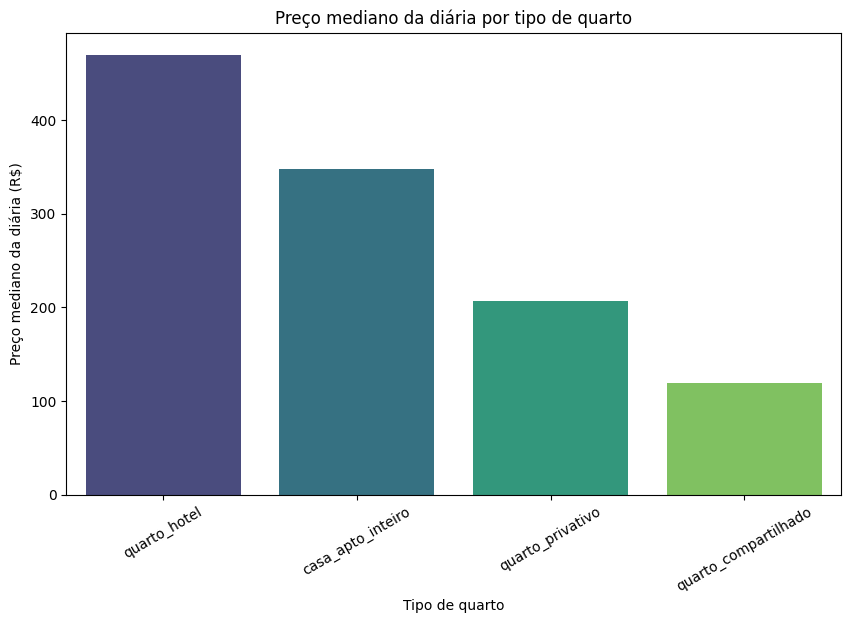

<class 'pandas.DataFrame'>
Index: 4 entries, 2 to 1
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tipo de quarto  4 non-null      str    
 1   Preço mediano   4 non-null      float64
dtypes: float64(1), str(1)
memory usage: 162.0 bytes


In [45]:


df_mediana = df_tratado_price_min.groupby("tipo_de_quarto")["preco"].median().reset_index()

df_mediana.columns = ["Tipo de quarto", "Preço mediano"]

df_mediana = df_mediana.sort_values(by="Preço mediano", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_mediana,
    x="Tipo de quarto",
    y="Preço mediano",
    palette="viridis"
)
plt.title("Preço mediano da diária por tipo de quarto")
plt.xlabel("Tipo de quarto")
plt.ylabel("Preço mediano da diária (R$)")
plt.xticks(rotation=30)
plt.show()
df_mediana.info()

In [46]:
df_tratado_price_min[df_tratado_price_min["bairro"] == "Copacabana"]["preco"].mean()

np.float64(475.0061401295315)

In [47]:
top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)

In [48]:
df_media_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)

# manter apenas bairros mais procurados
df_media_acomodacao = df_media_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)

In [49]:
df_media_acomodacao = df_media_acomodacao.sort_values("preco", ascending=False)

C:\Users\XE234PC\AppData\Local\Temp\ipykernel_32980\2527895257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


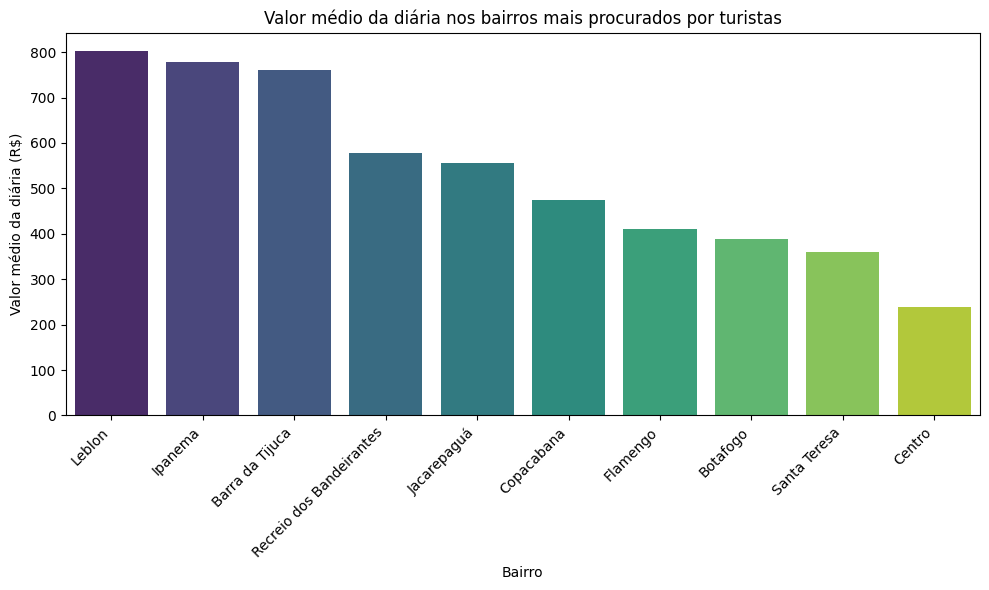

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor médio da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor médio da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\XE234PC\AppData\Local\Temp\ipykernel_32980\432334777.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


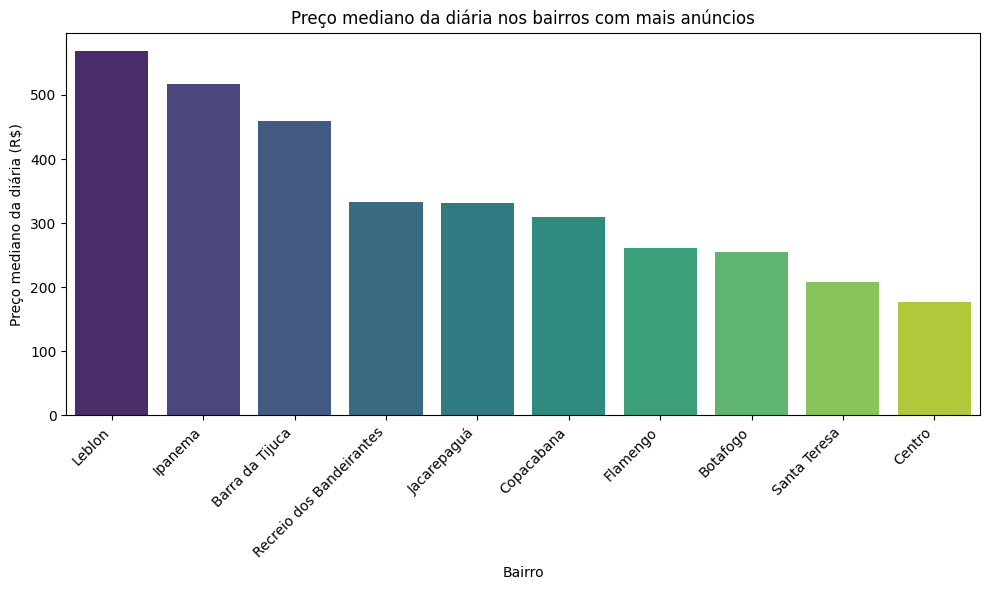

In [51]:
top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


df_mediana_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
)


df_mediana_acomodacao = df_mediana_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


df_mediana_acomodacao = df_mediana_acomodacao.sort_values(
    "preco",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Preço mediano da diária nos bairros com mais anúncios")
plt.xlabel("Bairro")
plt.ylabel("Preço mediano da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [52]:
df_mediana_bairros = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
    .rename(columns={"preco": "mediana_preco"})
    .sort_values("mediana_preco", ascending=False)
    .reset_index(drop=True)
)

df_mediana_bairros

,bairro,mediana_preco
0,Anchieta,2531.0
1,Joá,1485.0
2,Zumbi,1323.0
3,Jacaré,855.0
4,Colégio,829.5
...,...,...
146,Cavalcanti,96.0
147,Cidade Universitária,95.0
148,Quintino Bocaiúva,94.0
149,Maria da Graça,93.0


In [53]:
df_contagem_bairros = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .count()
    .reset_index()
    .rename(columns={"preco": "total_anuncios"})
    .sort_values("total_anuncios", ascending=True)
    .reset_index(drop=True)
)

df_contagem_bairros

,bairro,total_anuncios
0,Caju,1
1,Cordovil,1
2,Gericinó,1
3,Mangueira,1
4,Zumbi,1
...,...,...
146,Recreio dos Bandeirantes,1972
147,Centro,2010
148,Barra da Tijuca,3195
149,Ipanema,3284


C:\Users\XE234PC\AppData\Local\Temp\ipykernel_32980\2148038413.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


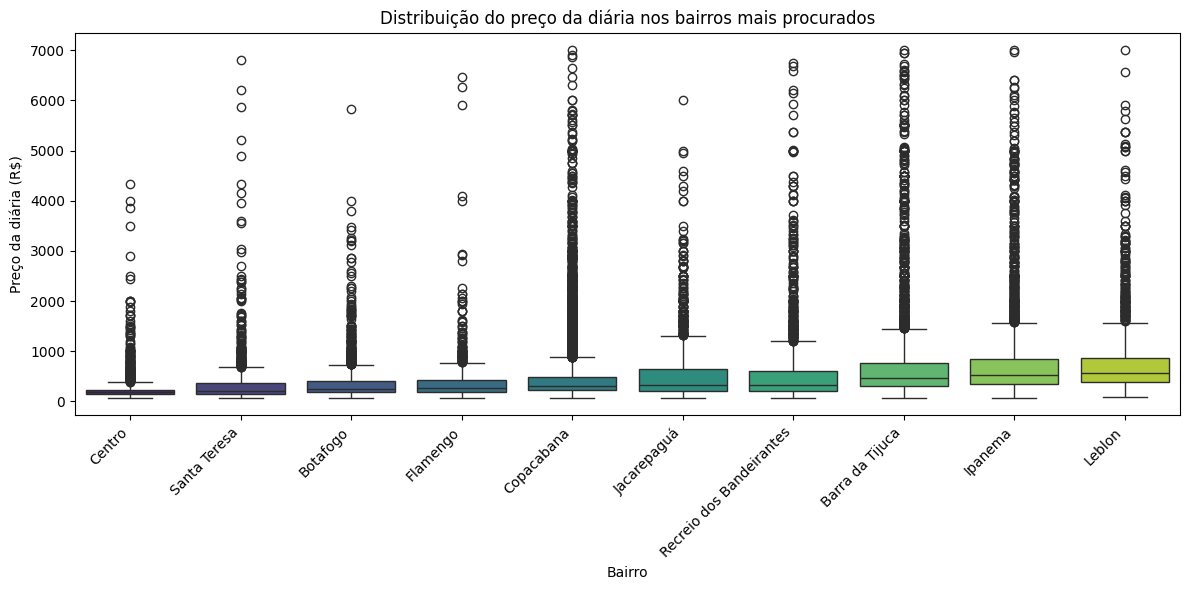

In [54]:
df_top_bairros = df_tratado_price_min.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


ordem_bairros = (
    df_top_bairros
    .groupby("bairro")["preco"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis"
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\XE234PC\AppData\Local\Temp\ipykernel_32980\3611848364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


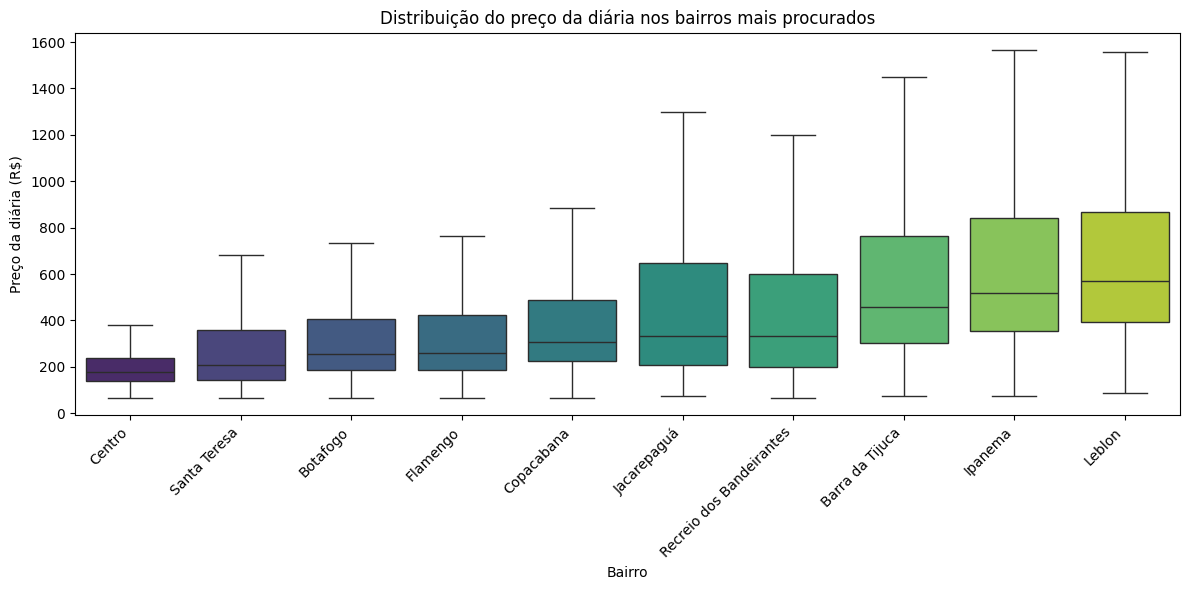

In [55]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis",
    showfliers=False
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [56]:
df_tratado_price_min.info()

<class 'pandas.DataFrame'>
Index: 37711 entries, 0 to 43067
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37711 non-null  float64
 1   hospedes                          37711 non-null  int64  
 2   quartos                           37711 non-null  float64
 3   camas                             37700 non-null  float64
 4   tipo_de_quarto                    37711 non-null  str    
 5   nota_avaliacao                    30097 non-null  float64
 6   noites_minimas                    37711 non-null  int64  
 7   quantidade_avaliacoes             37711 non-null  int64  
 8   tipo_de_propriedade               37711 non-null  str    
 9   latitude                          37711 non-null  float64
 10  longitude                         37711 non-null  float64
 11  bairro                            37711 non-null  str    
 12  ano                 

In [61]:
variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "hospedes",
    "noites_minimas",
    "tipo_quarto_casa_apto_inteiro",
    "tipo_quarto_quarto_compartilhado",
    "tipo_quarto_quarto_hotel",
    "tipo_quarto_quarto_privativo",
    "tipo_de_propriedade_grupo",
    "ipca_mensal",
    "ipca_acumulado_ano"
    #"tipo_de_quarto"
]

df_corr = df_tratado_price_min[variaveis]

#df_corr = df_corr[df_corr["tipo_quarto_Hotel room"] == 1]

In [62]:
corr_matrix = df_corr.corr()

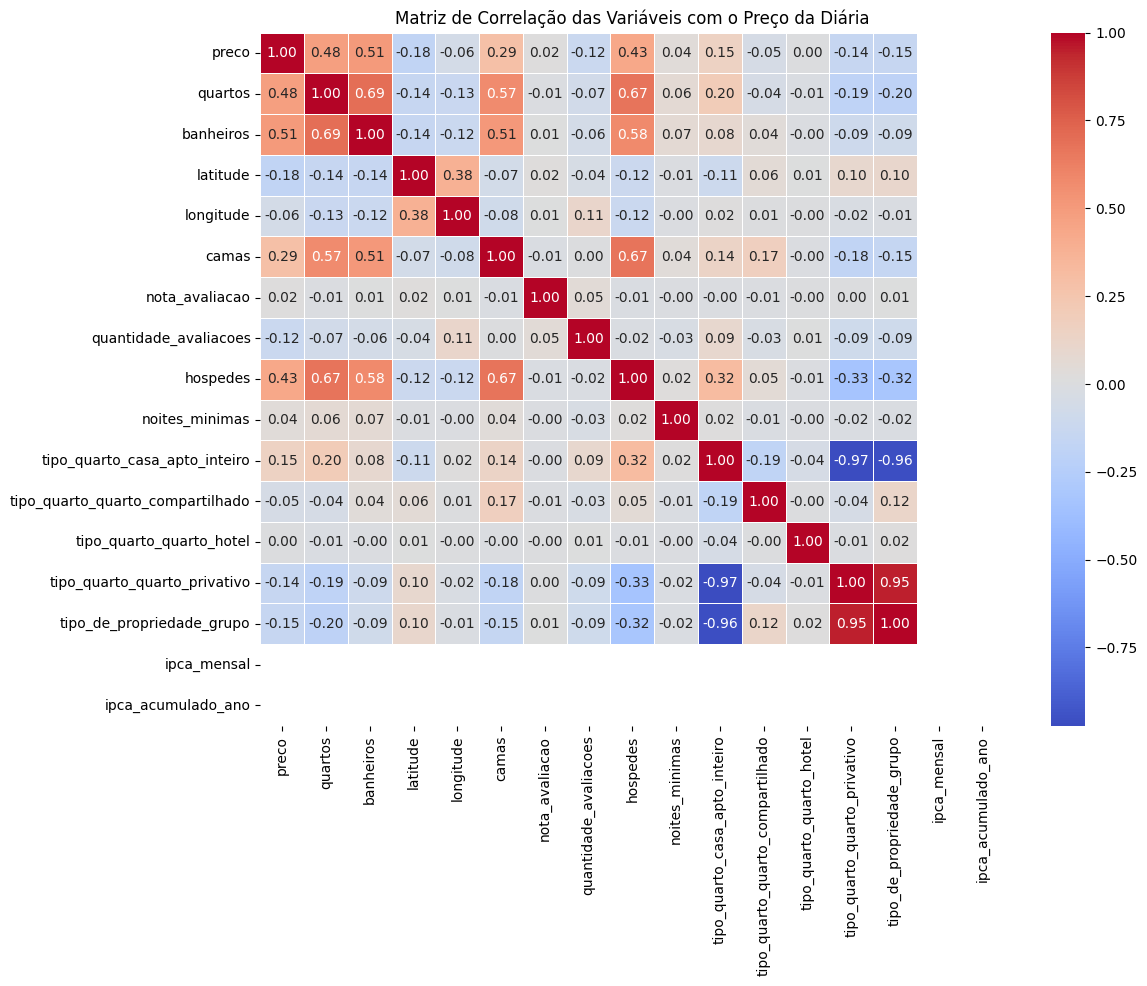

In [63]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()

In [93]:
# variável alvo
y = df_tratado_price_min["preco"]

# variáveis explicativas
X = df_tratado_price_min.drop(columns=["preco", "ano_mes", "lat_bin", "lon_bin", "bairro_encode", "bairro", "tipo_de_propriedade", "tipo_de_quarto", "ano", "mes", "ipca_acumulado_ano", "ipca_mensal"])
X.head()


,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,latitude,longitude,banheiros,tipo_quarto_casa_apto_inteiro,tipo_quarto_quarto_compartilhado,tipo_quarto_quarto_hotel,tipo_quarto_quarto_privativo,tipo_de_propriedade_grupo
0,4,2.0,3.0,4.93,2,86,-22.982818,-43.222457,1.5,1,0,0,0,1
1,2,1.0,1.0,NaN,5,0,-22.984090,-43.191770,2.0,1,0,0,0,1
2,4,1.0,1.0,NaN,1,0,-22.814911,-43.379011,1.0,1,0,0,0,1
4,4,1.0,1.0,4.91,2,11,-23.010000,-43.344820,1.0,1,0,0,0,1
5,6,2.0,6.0,4.93,2,89,-22.970696,-43.186048,2.0,1,0,0,0,1


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [95]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

modelo = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [96]:
y_pred = modelo.predict(X_test)

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_full = mean_absolute_error(y_test, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred))
r2_full = r2_score(y_test, y_pred)

In [98]:
print("MODELO COMPLETO SEM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

MODELO COMPLETO SEM LOG
MAE: 260.74766955394495
RMSE: 524.3939071936775
R²: 0.4210715754741491


In [99]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

banheiros                           0.178693
longitude                           0.141800
latitude                            0.139076
quartos                             0.115501
hospedes                            0.112204
noites_minimas                      0.084203
nota_avaliacao                      0.076280
camas                               0.057460
quantidade_avaliacoes               0.054083
tipo_quarto_casa_apto_inteiro       0.025791
tipo_de_propriedade_grupo           0.011139
tipo_quarto_quarto_privativo        0.003026
tipo_quarto_quarto_compartilhado    0.000674
tipo_quarto_quarto_hotel            0.000072
dtype: float64


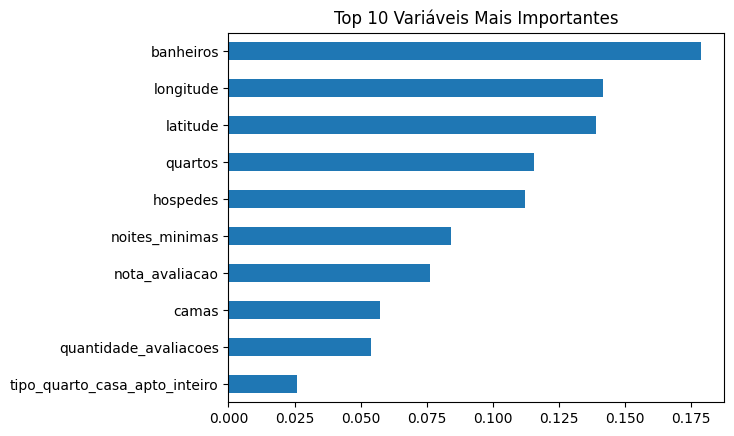

In [100]:
importancias.head(10).plot(kind="barh")
plt.title("Top 10 Variáveis Mais Importantes")
plt.gca().invert_yaxis()
plt.show()
#grafico com as variaveis mais importantes

In [101]:
top_features = importancias.head(10).index.tolist()

print("Variáveis selecionadas:", top_features)
#pega as top variaveis mais importantes

Variáveis selecionadas: ['banheiros', 'longitude', 'latitude', 'quartos', 'hospedes', 'noites_minimas', 'nota_avaliacao', 'camas', 'quantidade_avaliacoes', 'tipo_quarto_casa_apto_inteiro']


In [102]:
X = X[top_features]
#redefine o X com essas variaveis

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#separa entre train/test novamente

In [104]:
modelo.fit(X_train, y_train)
#treina o modelo novamente

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [105]:
y_pred = modelo.predict(X_test)
#previsao

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODELO REDUZIDO SEM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
#avalia o desempenho do modelo

MODELO REDUZIDO SEM LOG
MAE: 259.649649549231
RMSE: 521.164073647585
R²: 0.4281810558775393


In [107]:
#MODELO COM TRANSFORMAÇÃO LOG
y = np.log(df_tratado_price_min["preco"])
X = df_tratado_price_min.drop(columns=["preco", "ano_mes", "lat_bin", "lon_bin", "bairro_encode", "bairro", "tipo_de_propriedade", "tipo_de_quarto", "ano", "mes", "ipca_acumulado_ano", "ipca_mensal"])



In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [109]:
modelo = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [110]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

In [111]:
mae_full = mean_absolute_error(y_test_real, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2_full = r2_score(y_test_real, y_pred)



In [112]:
print("MODELO COMPLETO COM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

MODELO COMPLETO COM LOG
MAE: 229.13271079579482
RMSE: 511.16112356852494
R²: 0.4499207900010209


In [113]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

latitude                            0.168575
banheiros                           0.147977
longitude                           0.127225
quartos                             0.125718
hospedes                            0.113990
nota_avaliacao                      0.078313
noites_minimas                      0.068117
quantidade_avaliacoes               0.061578
tipo_quarto_casa_apto_inteiro       0.048042
camas                               0.044976
tipo_de_propriedade_grupo           0.009547
tipo_quarto_quarto_compartilhado    0.003462
tipo_quarto_quarto_privativo        0.002229
tipo_quarto_quarto_hotel            0.000250
dtype: float64


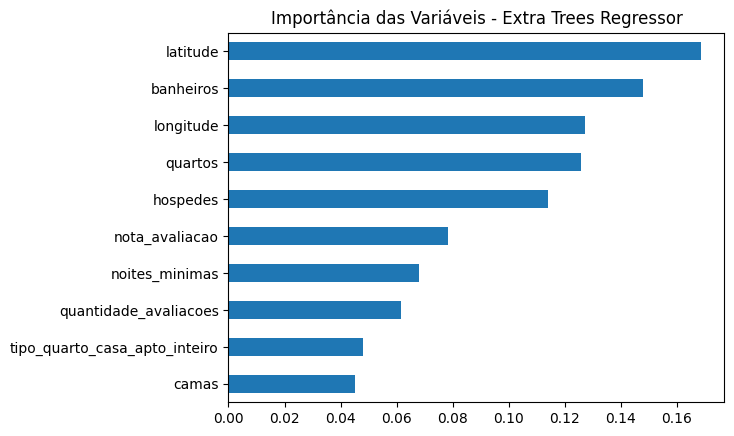

In [114]:
importancias.head(10).plot(kind="barh")
plt.title("Importância das Variáveis - Extra Trees Regressor")
plt.gca().invert_yaxis()
plt.show()
#grafico com as variaveis mais importantes

In [115]:
top_features = importancias.head(10).index.tolist()
X = X[top_features]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#separa entre train/test novamente

In [117]:
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [118]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


In [119]:
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

In [120]:
print("MODELO REDUZIDO COM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MODELO REDUZIDO COM LOG
MAE: 228.9662400432077
RMSE: 510.6142682638492
R²: 0.4510971424675826


latitude                         0.172758
banheiros                        0.131513
quartos                          0.131419
longitude                        0.129879
hospedes                         0.125441
nota_avaliacao                   0.077637
noites_minimas                   0.069222
quantidade_avaliacoes            0.063894
tipo_quarto_casa_apto_inteiro    0.051089
camas                            0.047148
dtype: float64


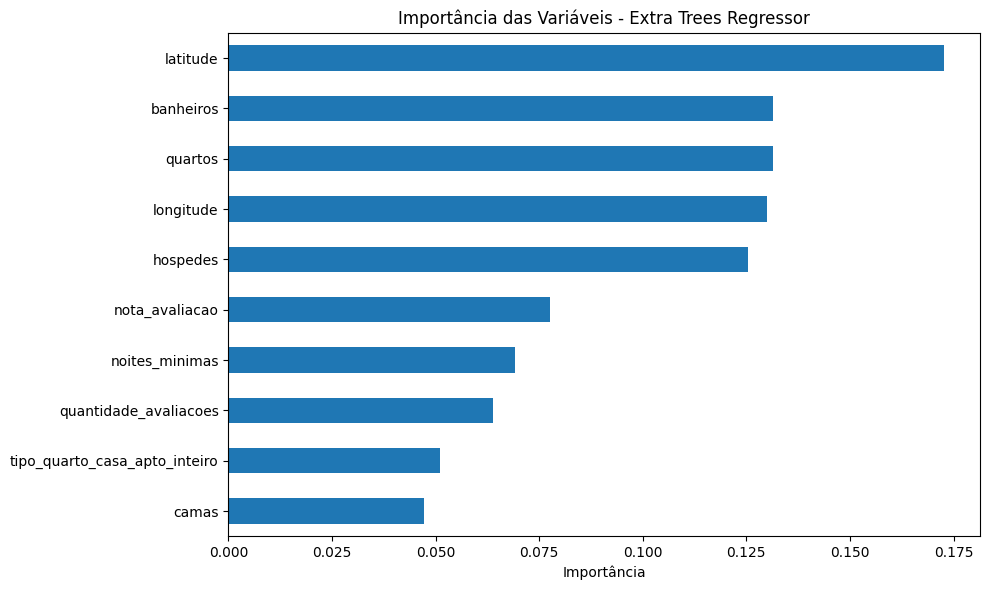

In [121]:
importancias_reduzido = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias_reduzido)

plt.figure(figsize=(10,6))
importancias_reduzido.plot(kind='barh')
plt.title("Importância das Variáveis - Extra Trees Regressor")
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

In [85]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


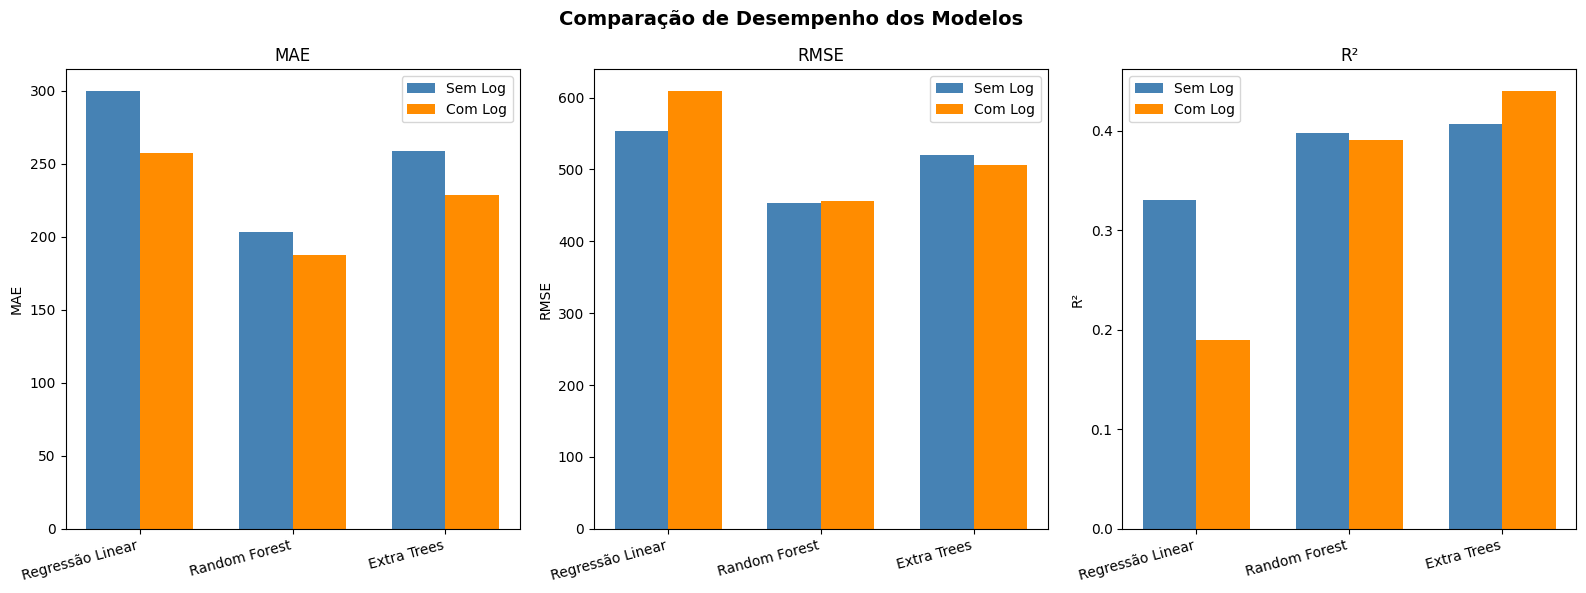

In [86]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_metricas = pd.read_excel(r"C:\Users\XE234PC\Downloads\MetricasModelos5.xlsx", index_col=0)

modelos = ["Reg_Linear", "Rand_Forest", "Ex_Trees"]
nomes_modelos = ["Regressão Linear", "Random Forest", "Extra Trees"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = {
    "MAE":  ("MAE_NLOG",  "MAE_LOG"),
    "RMSE": ("RMSE_NLOG", "RMSE_LOG"),
    "R²":   ("R2_NLOG",   "R2_LOG")
}

x = np.arange(len(modelos))
largura = 0.35

for ax, (metrica, (sem_log, com_log)) in zip(axes, metricas.items()):
    valores_sem_log = df_metricas.loc[sem_log, modelos].values.astype(float)
    valores_com_log = df_metricas.loc[com_log, modelos].values.astype(float)

    # substitui valores absurdos por NaN para não distorcer o gráfico
    limite = 1e6
    valores_sem_log = np.where(valores_sem_log > limite, np.nan, valores_sem_log)
    valores_com_log = np.where(valores_com_log > limite, np.nan, valores_com_log)

    ax.bar(x - largura/2, valores_sem_log, width=largura, label="Sem Log", color="steelblue")
    ax.bar(x + largura/2, valores_com_log, width=largura, label="Com Log", color="darkorange")

    ax.set_xticks(x)
    ax.set_xticklabels(nomes_modelos, rotation=15, ha="right")
    ax.set_title(metrica)
    ax.set_ylabel(metrica)
    ax.legend()

plt.suptitle("Comparação de Desempenho dos Modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=300, bbox_inches="tight")
plt.show()
